# Client Distribution Analysis

This notebook plots client-side label distributions for Dolly and Wizard splits.

- `data_dolly/10` is the legacy Dolly Dirichlet split.
- `data_dolly_stratified/10` is the stratified Dolly split that preserves client sizes.
- `data_wiz/10` is the legacy Wizard split provided with the repo.
- `data_wiz_stratified/10` is the Wizard split stratified by derived task-family and instruction-length labels.

The most useful views are the normalized proportion plots and the deviation-from-global comparisons. If clients share the same distribution, the stacked bars should look nearly identical and the deviation values should stay close to zero.


In [1]:
import json
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

from client_data_allocation import wizard_stratification_labels

plt.style.use("seaborn-v0_8-whitegrid")
pd.options.display.float_format = lambda x: f"{x:0.3f}"

REPO_ROOT = Path.cwd()
DOLLY_LEGACY_ROOT = REPO_ROOT / "data_dolly" / "10"
DOLLY_STRATIFIED_ROOT = REPO_ROOT / "data_dolly_stratified" / "10"
WIZARD_LEGACY_ROOT = REPO_ROOT / "data_wiz" / "10"
WIZARD_STRATIFIED_ROOT = REPO_ROOT / "data_wiz_stratified" / "10"


In [2]:
def load_json(path: Path):
    with open(path) as f:
        return json.load(f)


def client_paths(split_root: Path):
    return sorted(
        split_root.glob("local_training_*.json"),
        key=lambda p: int(p.stem.split("_")[-1]),
    )


def load_local_records(split_root: Path):
    records_by_client = []
    for client_path in client_paths(split_root):
        records_by_client.append(load_json(client_path))
    return records_by_client


def dolly_label_fn(records):
    return [row["category"] for row in records], None


def wizard_label_fn(records):
    return wizard_stratification_labels(records, num_length_buckets=5)


def load_split(split_root: Path, label_fn, label_name: str):
    records_by_client = load_local_records(split_root)
    if (split_root / "global_training.json").exists():
        global_training = load_json(split_root / "global_training.json")
    else:
        global_training = [row for client_records in records_by_client for row in client_records]

    global_labels, label_metadata = label_fn(global_training)
    labels = sorted(set(global_labels))
    global_counts = Counter(global_labels)
    global_props = pd.Series(global_counts, index=labels, dtype=float) / len(global_training)

    record_to_label = {
        json.dumps(row, sort_keys=True): label
        for row, label in zip(global_training, global_labels)
    }

    client_rows = []
    client_labels = []
    for client_id, client_records in enumerate(records_by_client):
        client_label_counts = Counter(
            record_to_label[json.dumps(row, sort_keys=True)]
            for row in client_records
        )
        client_rows.append(pd.Series(client_label_counts, index=labels, dtype=float).fillna(0.0))
        client_labels.append(f"client_{client_id}")

    count_df = pd.DataFrame(client_rows, index=client_labels)[labels].astype(int)
    prop_df = count_df.div(count_df.sum(axis=1), axis=0)
    deviation_df = (prop_df - global_props).mul(100.0)
    summary_df = pd.DataFrame(
        {
            "size": count_df.sum(axis=1),
            "max_abs_diff_pp": deviation_df.abs().max(axis=1),
            "mean_abs_diff_pp": deviation_df.abs().mean(axis=1),
        }
    )

    return {
        "root": split_root,
        "label_name": label_name,
        "label_metadata": label_metadata,
        "labels": labels,
        "count_df": count_df,
        "prop_df": prop_df,
        "global_props": global_props,
        "deviation_df": deviation_df,
        "summary_df": summary_df,
    }


def plot_split(split, title: str, max_legend_labels: int = 25):
    labels = split["labels"]
    colors = list(plt.get_cmap("tab20").colors)
    colors = [colors[index % len(colors)] for index in range(len(labels))]

    plot_df = pd.concat(
        [pd.DataFrame([split["global_props"]], index=["global"]), split["prop_df"]],
        axis=0,
    )

    fig, ax = plt.subplots(figsize=(14, 6))
    plot_df.plot(kind="bar", stacked=True, ax=ax, color=colors, width=0.85)
    ax.set_title(f"{title}{split['label_name']} proportions")
    ax.set_ylabel("share of dataset")
    ax.set_xlabel("")
    ax.set_ylim(0, 1.0)
    ax.tick_params(axis="x", rotation=45)

    handles, legend_labels = ax.get_legend_handles_labels()
    if len(legend_labels) <= max_legend_labels:
        ax.legend(handles, legend_labels, title=split["label_name"], bbox_to_anchor=(1.02, 1.0), loc="upper left")
    else:
        ax.legend().remove()
        ax.text(
            1.01,
            0.5,
            f"{len(legend_labels)} labels; legend hidden",
            transform=ax.transAxes,
            va="center",
        )
    fig.tight_layout()
    return fig, ax


def comparison_table(legacy, stratified):
    return pd.DataFrame(
        {
            "legacy_max_abs_diff_pp": legacy["summary_df"]["max_abs_diff_pp"],
            "stratified_max_abs_diff_pp": stratified["summary_df"]["max_abs_diff_pp"],
            "legacy_mean_abs_diff_pp": legacy["summary_df"]["mean_abs_diff_pp"],
            "stratified_mean_abs_diff_pp": stratified["summary_df"]["mean_abs_diff_pp"],
        }
    )


def plot_comparison(comparison, title: str):
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))

    comparison[["legacy_max_abs_diff_pp", "stratified_max_abs_diff_pp"]].plot(
        kind="bar",
        ax=axes[0],
        color=["#D95F02", "#1B9E77"],
    )
    axes[0].set_title("Max absolute deviation from global")
    axes[0].set_ylabel("percentage points")
    axes[0].set_xlabel("")
    axes[0].tick_params(axis="x", rotation=45)

    comparison[["legacy_mean_abs_diff_pp", "stratified_mean_abs_diff_pp"]].plot(
        kind="bar",
        ax=axes[1],
        color=["#D95F02", "#1B9E77"],
    )
    axes[1].set_title("Mean absolute deviation from global")
    axes[1].set_ylabel("percentage points")
    axes[1].set_xlabel("")
    axes[1].tick_params(axis="x", rotation=45)

    fig.suptitle(title, y=1.02)
    fig.tight_layout()
    return fig, axes


In [3]:
dolly_legacy = load_split(DOLLY_LEGACY_ROOT, dolly_label_fn, "category")
dolly_stratified = load_split(DOLLY_STRATIFIED_ROOT, dolly_label_fn, "category")
dolly_comparison = comparison_table(dolly_legacy, dolly_stratified)

dolly_comparison


,legacy_max_abs_diff_pp,stratified_max_abs_diff_pp,legacy_mean_abs_diff_pp,stratified_mean_abs_diff_pp
client_0,20.764,0.022,11.008,0.010
client_1,27.001,0.019,11.113,0.011
client_2,21.069,0.037,9.053,0.018
client_3,31.356,0.037,11.446,0.020
client_4,31.069,0.021,10.373,0.008
client_5,24.563,0.097,10.542,0.073
client_6,43.538,0.031,12.363,0.016
client_7,23.451,0.077,8.758,0.030
client_8,28.357,0.026,11.835,0.012
client_9,22.286,0.087,10.527,0.049


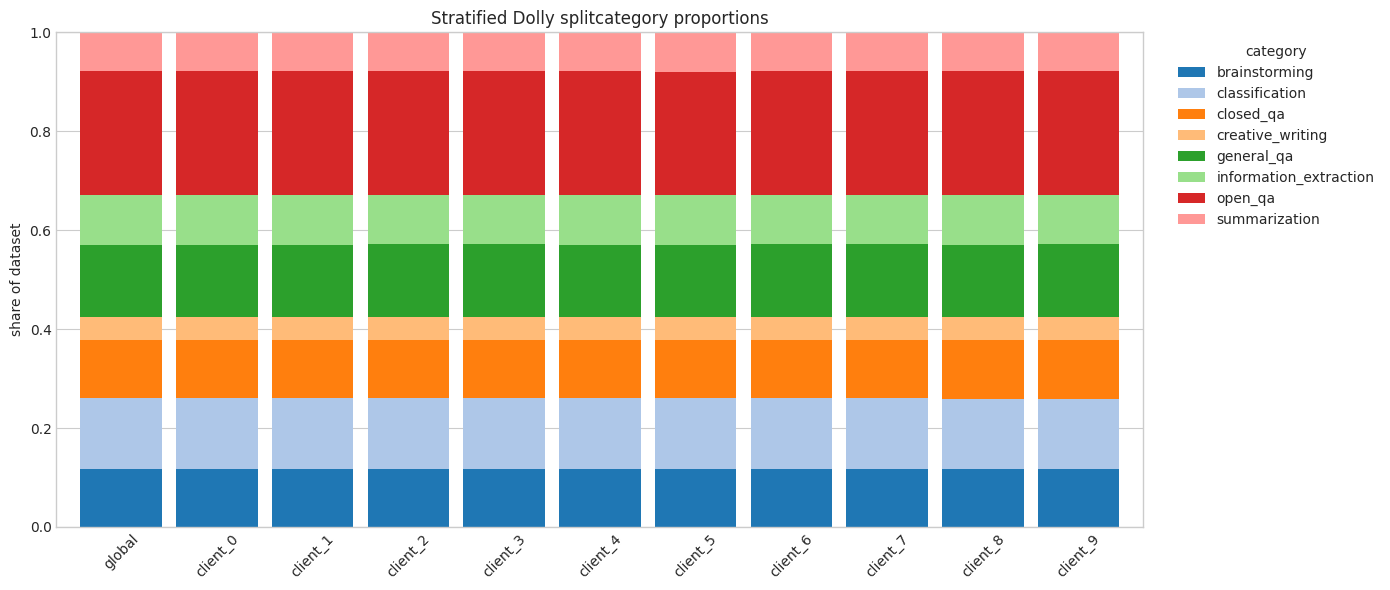

Saved figure to: /home/trieu.vy.tran/FederatedLLM/dolly_stratified_distribution.png


,size,max_abs_diff_pp,mean_abs_diff_pp
client_1,2831,0.019,0.011
client_4,2253,0.021,0.008
client_0,1820,0.022,0.010
client_8,1533,0.026,0.012
client_6,1518,0.031,0.016
client_2,1773,0.037,0.018
client_3,1299,0.037,0.020
client_7,896,0.077,0.030
client_9,443,0.087,0.049
client_5,565,0.097,0.073


In [4]:
fig, ax = plot_split(dolly_stratified, "Stratified Dolly split")
png_path = REPO_ROOT / "dolly_stratified_distribution.png"
fig.savefig(png_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved figure to: {png_path}")

dolly_stratified["summary_df"].sort_values("max_abs_diff_pp")


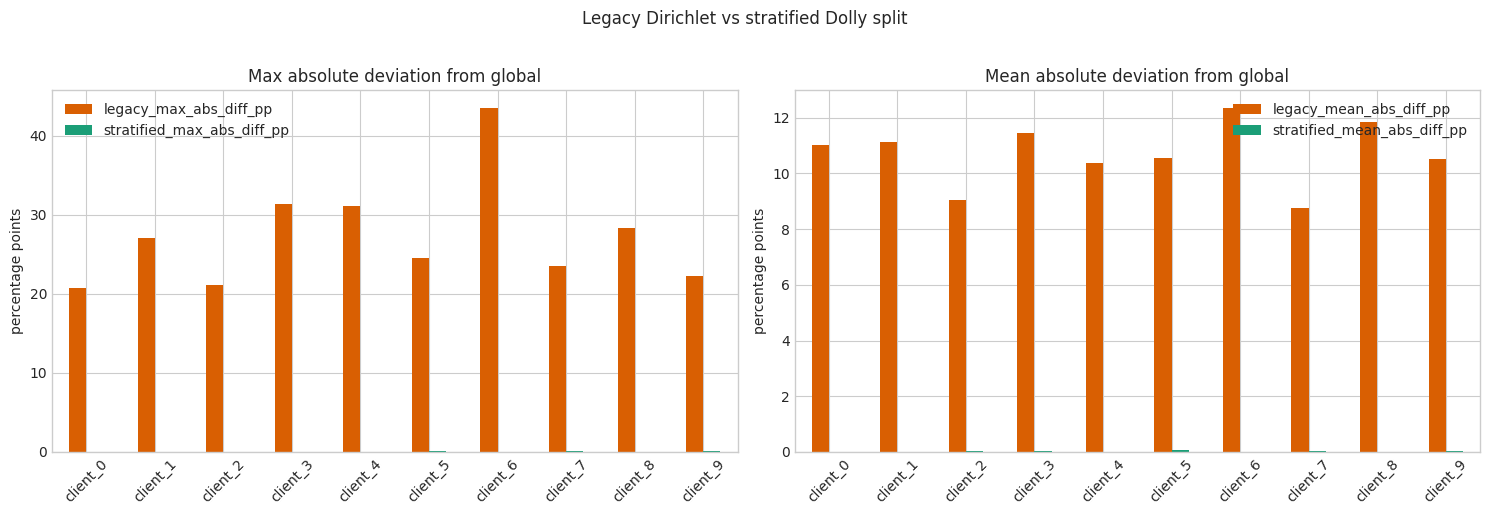

,legacy_max_abs_diff_pp,stratified_max_abs_diff_pp,legacy_mean_abs_diff_pp,stratified_mean_abs_diff_pp
client_0,20.764,0.022,11.008,0.010
client_1,27.001,0.019,11.113,0.011
client_2,21.069,0.037,9.053,0.018
client_3,31.356,0.037,11.446,0.020
client_4,31.069,0.021,10.373,0.008
client_5,24.563,0.097,10.542,0.073
client_6,43.538,0.031,12.363,0.016
client_7,23.451,0.077,8.758,0.030
client_8,28.357,0.026,11.835,0.012
client_9,22.286,0.087,10.527,0.049


In [5]:
fig, axes = plot_comparison(dolly_comparison, "Legacy Dirichlet vs stratified Dolly split")
plt.show()

dolly_comparison.sort_index()


In [6]:
wizard_legacy = load_split(WIZARD_LEGACY_ROOT, wizard_label_fn, "derived task/length label")
wizard_stratified = load_split(WIZARD_STRATIFIED_ROOT, wizard_label_fn, "derived task/length label")
wizard_comparison = comparison_table(wizard_legacy, wizard_stratified)

wizard_comparison


,legacy_max_abs_diff_pp,stratified_max_abs_diff_pp,legacy_mean_abs_diff_pp,stratified_mean_abs_diff_pp
client_0,0.789,0.013,0.121,0.005
client_1,0.539,0.013,0.109,0.005
client_2,0.940,0.013,0.126,0.004
client_3,1.254,0.011,0.137,0.004
client_4,0.746,0.013,0.115,0.005
client_5,0.520,0.013,0.110,0.005
client_6,1.112,0.013,0.138,0.005
client_7,1.676,0.013,0.129,0.005
client_8,0.287,0.011,0.082,0.004
client_9,0.344,0.013,0.095,0.005


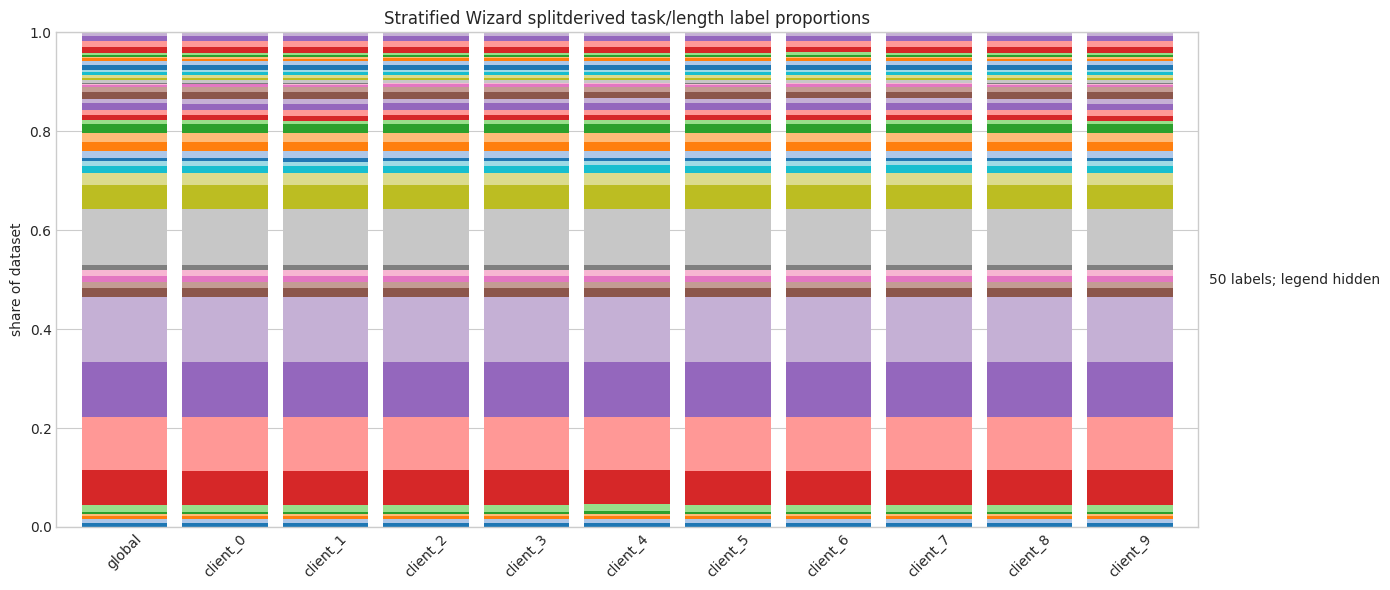

Saved figure to: /home/trieu.vy.tran/FederatedLLM/wizard_stratified_distribution.png


,size,max_abs_diff_pp,mean_abs_diff_pp
client_8,6999,0.011,0.004
client_3,6999,0.011,0.004
client_1,6999,0.013,0.005
client_2,6999,0.013,0.004
client_4,6999,0.013,0.005
client_5,6999,0.013,0.005
client_6,6999,0.013,0.005
client_7,6999,0.013,0.005
client_9,6999,0.013,0.005
client_0,6999,0.013,0.005


In [7]:
fig, ax = plot_split(wizard_stratified, "Stratified Wizard split")
png_path = REPO_ROOT / "wizard_stratified_distribution.png"
fig.savefig(png_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved figure to: {png_path}")

wizard_stratified["summary_df"].sort_values("max_abs_diff_pp")


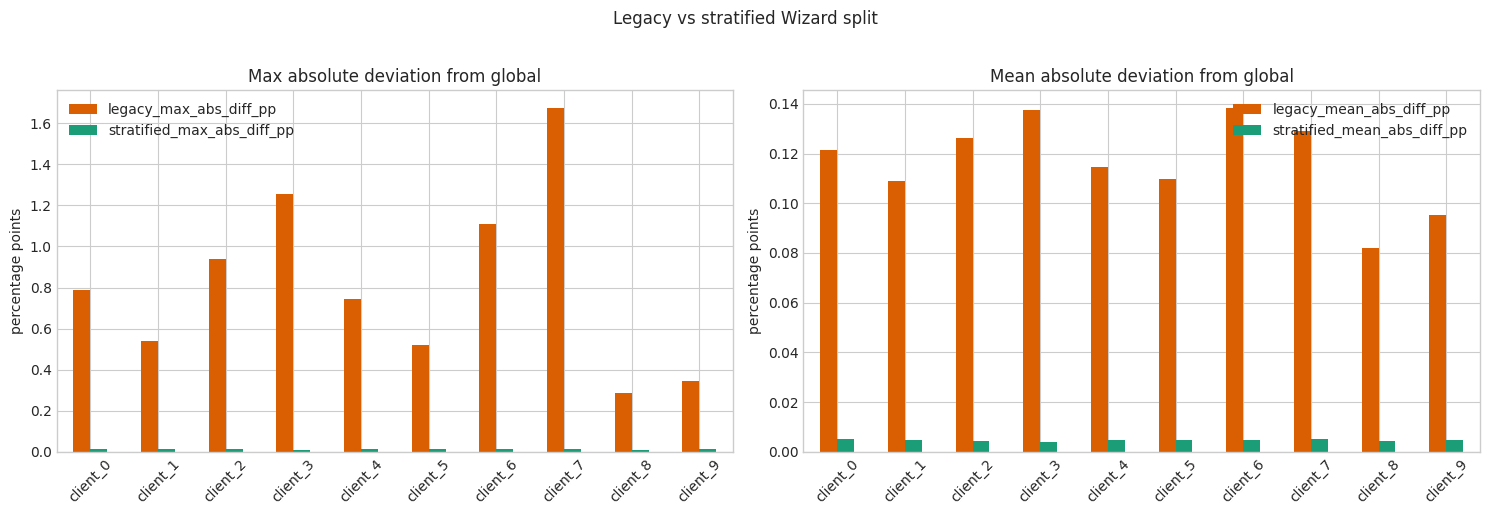

,legacy_max_abs_diff_pp,stratified_max_abs_diff_pp,legacy_mean_abs_diff_pp,stratified_mean_abs_diff_pp
client_0,0.789,0.013,0.121,0.005
client_1,0.539,0.013,0.109,0.005
client_2,0.940,0.013,0.126,0.004
client_3,1.254,0.011,0.137,0.004
client_4,0.746,0.013,0.115,0.005
client_5,0.520,0.013,0.110,0.005
client_6,1.112,0.013,0.138,0.005
client_7,1.676,0.013,0.129,0.005
client_8,0.287,0.011,0.082,0.004
client_9,0.344,0.013,0.095,0.005


In [8]:
fig, axes = plot_comparison(wizard_comparison, "Legacy vs stratified Wizard split")
plt.show()

wizard_comparison.sort_index()


In [9]:
summary = pd.DataFrame(
    {
        "dolly_legacy_max_pp": dolly_comparison["legacy_max_abs_diff_pp"],
        "dolly_stratified_max_pp": dolly_comparison["stratified_max_abs_diff_pp"],
        "wizard_legacy_max_pp": wizard_comparison["legacy_max_abs_diff_pp"],
        "wizard_stratified_max_pp": wizard_comparison["stratified_max_abs_diff_pp"],
    }
)

summary


,dolly_legacy_max_pp,dolly_stratified_max_pp,wizard_legacy_max_pp,wizard_stratified_max_pp
client_0,20.764,0.022,0.789,0.013
client_1,27.001,0.019,0.539,0.013
client_2,21.069,0.037,0.940,0.013
client_3,31.356,0.037,1.254,0.011
client_4,31.069,0.021,0.746,0.013
client_5,24.563,0.097,0.520,0.013
client_6,43.538,0.031,1.112,0.013
client_7,23.451,0.077,1.676,0.013
client_8,28.357,0.026,0.287,0.011
client_9,22.286,0.087,0.344,0.013
